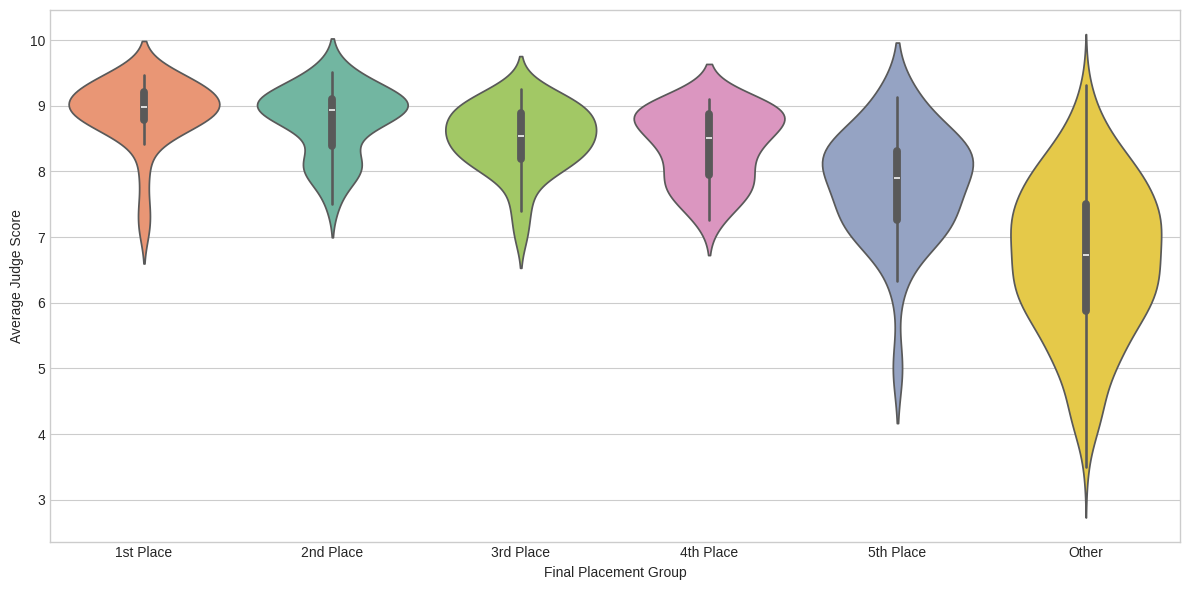

In [29]:
# Generating violin plot of average judge scores by final placement group

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
df = pd.read_csv(file_path)

# Step 1: Extract all judge score columns
juge_score_cols = [col for col in df.columns if 'judge' in col and 'score' in col]

# Replace 'N/A' with NaN and convert to float
df[juge_score_cols] = df[juge_score_cols].replace('N/A', np.nan).astype(float)

# Step 2: Calculate average judge score per contestant (ignoring 0 and NaN)
def compute_avg_score(row):
    scores = row[juge_score_cols]
    valid_scores = scores[(~scores.isna()) & (scores != 0)]
    if len(valid_scores) == 0:
        return np.nan
    return valid_scores.mean()

df['avg_judge_score'] = df.apply(compute_avg_score, axis=1)

# Step 3: Categorize final placement
def categorize_placement(p):
    if p == 1:
        return '1st Place'
    elif p == 2:
        return '2nd Place'
    elif p == 3:
        return '3rd Place'
    elif p == 4:
        return '4th Place'
    elif p == 5:
        return '5th Place'
    else:
        return 'Other'

df['placement_group'] = df['placement'].apply(categorize_placement)

# Drop rows with missing average score
plot_df = df.dropna(subset=['avg_judge_score'])

# Step 4: Plot violin plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
order = ['1st Place', '2nd Place', '3rd Place', '4th Place', '5th Place', 'Other']
sns.violinplot(data=plot_df, x='placement_group', y='avg_judge_score', order=order, palette='Set2', inner='box', hue='placement_group', legend=False)
plt.title('')
plt.xlabel('Final Placement Group')
plt.ylabel('Average Judge Score')
plt.tight_layout()

# Display plot directly
plt.show()
